<H1>UNEMPLOYMENT</H1>

<h2>IMPORTING LIBRARIES AND DATA</H2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1140&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=STLUR&scale=left&cosd=1990-01-01&coed=2025-12-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-27&revision_date=2026-03-27&nd=1990-01-01"


<h2>Unemployment Data imported from FRED, 1990 TO 2025 -  35 YEARS </h2>

In [3]:
unemployment = pd.read_csv(URL)
unemployment.head(5)

,observation_date,STLUR
0,1990-01-01,5.6
1,1990-02-01,5.6
2,1990-03-01,5.5
3,1990-04-01,5.5
4,1990-05-01,5.6


<h3>Uniqueness verification in column observation_date</h3>

In [4]:
unemployment['observation_date'].is_unique

True

<h3>Find empty values</h3>

In [5]:
unemployment[unemployment.isna().any(axis=1)] ## Only one value was empty so i will complete it with previous month

,observation_date,STLUR
429,2025-10-01,NaN


<h3>Completing Empty values</h3>

In [6]:
unemployment = unemployment.ffill() ##Fills empty values with the previouss value

In [7]:
unemployment[unemployment.isna().any(axis=1)] ##there are none empty values now

,observation_date,STLUR


<h2>Verification and Change of Datatypes</h2>

In [8]:
unemployment.dtypes

,0
observation_date,object
STLUR,float64


In [9]:
unemployment['observation_date'] = pd.to_datetime(unemployment['observation_date'])
unemployment.dtypes

,0
observation_date,datetime64[ns]
STLUR,float64


<h3>Extract Year and Month from observation date</h3>

In [10]:
unemployment['Month'] = unemployment['observation_date'].dt.month
unemployment['Year'] = unemployment['observation_date'].dt.year
unemployment['Year-Month'] = (unemployment['Year'].astype(str) + '-' + unemployment['Month'].astype(str))
unemployment.head(3)

,observation_date,STLUR,Month,Year,Year-Month
0,1990-01-01,5.6,1,1990,1990-1
1,1990-02-01,5.6,2,1990,1990-2
2,1990-03-01,5.5,3,1990,1990-3


In [11]:
unemployment.dtypes

,0
observation_date,datetime64[ns]
STLUR,float64
Month,int32
Year,int32
Year-Month,object


<h2>Data Graph</h2>

<h3>Using Matplotlib</h3>

(array([13., 52., 43., 38., 42., 37., 41., 24., 44., 17., 19., 16.,  5.,
         3., 10.,  5.,  8.,  8.,  4.,  1.,  0.,  0.,  1.,  1.]),
 array([ 2.7,  3.1,  3.5,  3.9,  4.3,  4.7,  5.1,  5.5,  5.9,  6.3,  6.7,
         7.1,  7.5,  7.9,  8.3,  8.7,  9.1,  9.5,  9.9, 10.3, 10.7, 11.1,
        11.5, 11.9, 12.3]),
 <BarContainer object of 24 artists>)

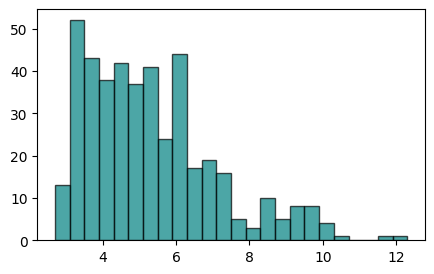

In [12]:
plt.figure(figsize=(5,3))
plt.hist(unemployment['STLUR'], bins= 24, color='teal', edgecolor='black', alpha=0.7)

<h3>Using Seaborn</h3>

<Axes: xlabel='STLUR', ylabel='Count'>

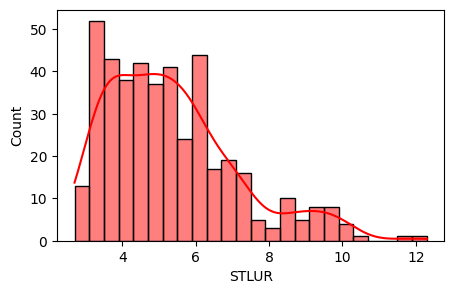

In [13]:
plt.figure(figsize=(5,3))
sns.histplot(unemployment['STLUR'] , color= 'Red' , bins= 24, kde=True)

<Axes: xlabel='Year', ylabel='STLUR'>

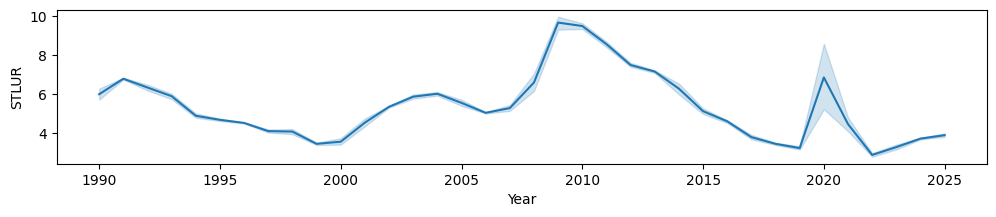

In [14]:
plt.figure(figsize= (12, 2))
sns.lineplot(x = unemployment['Year'], y= unemployment['STLUR'])

Text(0, 0.5, 'Unemployment Rate (%)')

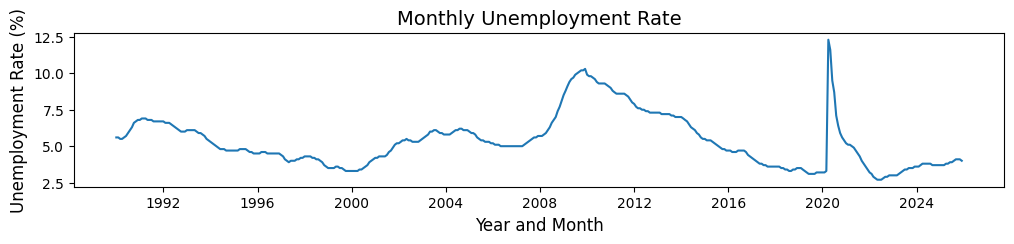

In [15]:
plt.figure(figsize= (12, 2))
sns.lineplot(data= unemployment, x = unemployment['observation_date'], y= unemployment['STLUR'])
plt.title('Monthly Unemployment Rate', fontsize=14)
plt.xlabel('Year and Month', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

<H1>TOTAL VEHICLE SALES</H1>

<h2>IMPORTING DIRECTLY FROM FRED USING  pandas_datareader</h2>

In [16]:
import pandas_datareader.data as web

In [17]:
Start = '1990-01-01'
End = '2025-12-31'
veh_sales = web.DataReader('TOTALSA', 'fred', Start, End)
veh_sales.head(3)

,TOTALSA
DATE,
1990-01-01,16.308
1990-02-01,14.363
1990-03-01,14.486


<h2>Reset index to make dataframe appearance</h2>

In [18]:
veh_sales = veh_sales.reset_index()

In [19]:
veh_sales.head(3)

,DATE,TOTALSA
0,1990-01-01,16.308
1,1990-02-01,14.363
2,1990-03-01,14.486


In [20]:
veh_sales

,DATE,TOTALSA
0,1990-01-01,16.308
1,1990-02-01,14.363
2,1990-03-01,14.486
3,1990-04-01,14.281
4,1990-05-01,14.022
...,...,...
427,2025-08-01,16.911
428,2025-09-01,16.985
429,2025-10-01,15.843
430,2025-11-01,16.006


In [21]:
veh_sales['DATE'] = pd.to_datetime(veh_sales['DATE'])
veh_sales.dtypes

,0
DATE,datetime64[ns]
TOTALSA,float64


<H2>GRAPH VEH SALES</H2>

<Axes: xlabel='DATE', ylabel='TOTALSA'>

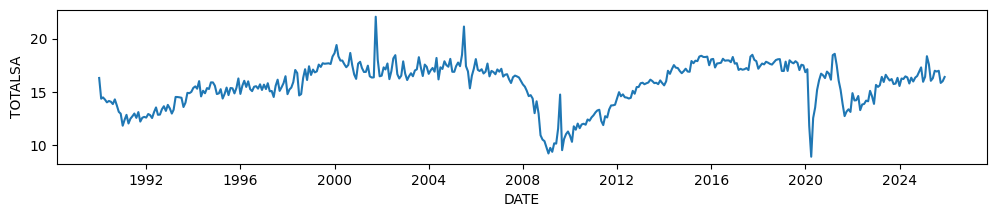

In [22]:
plt.figure(figsize=(12,2))
sns.lineplot(data= veh_sales, x= veh_sales['DATE'] , y= veh_sales['TOTALSA'])

<h1>UNEMPLOYMENT RATES VS VEHICLE SALES</h1>

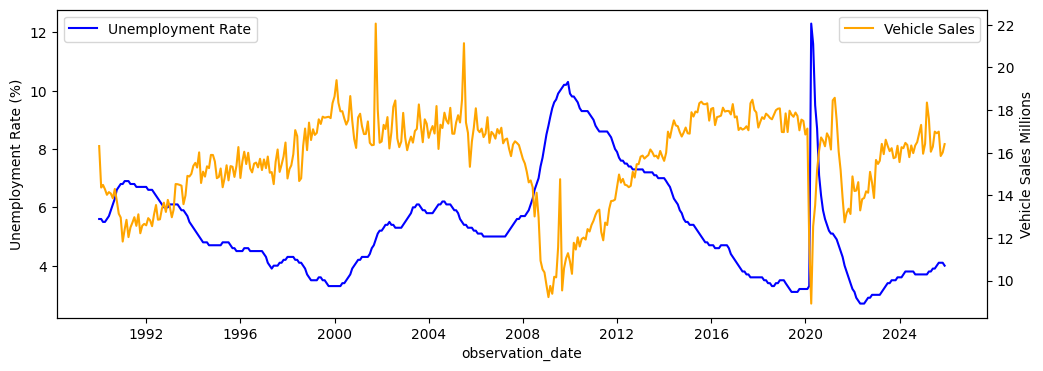

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# First line (blue)
sns.lineplot(
    data=unemployment,
    x='observation_date',
    y='STLUR',
    ax=ax1,
    color='blue',
    label='Unemployment Rate'
)
ax1.set_ylabel('Unemployment Rate (%)')

# Second axis
ax2 = ax1.twinx()

# Second line (yellow/orange)
sns.lineplot(
    data=veh_sales,
    x='DATE',
    y='TOTALSA',
    ax=ax2,
    color='orange',
    label='Vehicle Sales'
)
ax2.set_ylabel('Vehicle Sales Millions')

plt.show()

<h1>INTEREST RATES</h1>

In [24]:
Start = '1990-01-01'
End = '2025-12-31'
interest_rates = web.DataReader('FEDFUNDS', 'fred', Start, End)
interest_rates.head(3)

,FEDFUNDS
DATE,
1990-01-01,8.23
1990-02-01,8.24
1990-03-01,8.28


<H2>SET INDEX AND COLUMNS</H2>

In [25]:
interest_rates = interest_rates.reset_index()

In [26]:
interest_rates.head(3)

,DATE,FEDFUNDS
0,1990-01-01,8.23
1,1990-02-01,8.24
2,1990-03-01,8.28


In [27]:
interest_rates['DATE'] = pd.to_datetime(interest_rates['DATE'])

<Axes: xlabel='DATE', ylabel='FEDFUNDS'>

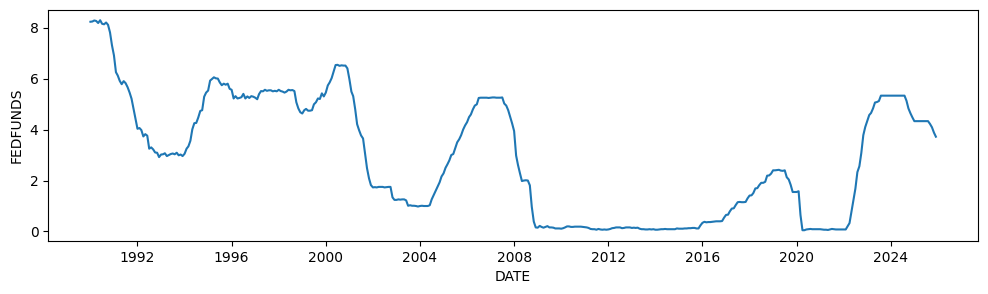

In [28]:
plt.figure(figsize= (12,3))
sns.lineplot(data = interest_rates, x = interest_rates['DATE'], y = interest_rates['FEDFUNDS'])


<h1>NORMALIZATION</h1>

In [29]:
unemployment['un_Normal'] = (unemployment['STLUR'] / unemployment['STLUR'].iloc[0]) * 100
veh_sales['veh_Normal'] = (veh_sales['TOTALSA'] / veh_sales['TOTALSA'].iloc[0]) * 100
interest_rates['int_Normal'] = (interest_rates['FEDFUNDS']/ interest_rates['FEDFUNDS'].iloc[0]) * 100

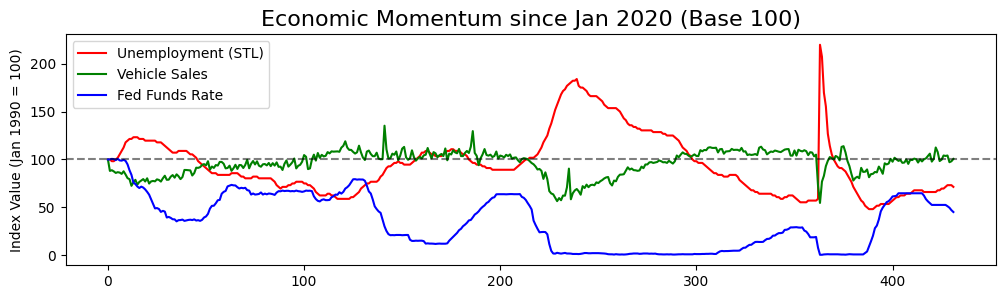

In [30]:
plt.figure(figsize=(12, 3))

# Plot each 'Normal' column
plt.plot(unemployment.index, unemployment['un_Normal'], label='Unemployment (STL)', color='red')
plt.plot(veh_sales.index, veh_sales['veh_Normal'], label='Vehicle Sales', color='green')
plt.plot(interest_rates.index, interest_rates['int_Normal'], label='Fed Funds Rate', color='blue')

# Add the 'Suelo' (The 100 line)
plt.axhline(100, color='black', linestyle='--', alpha=0.5)

plt.title('Economic Momentum since Jan 2020 (Base 100)', fontsize=16)
plt.ylabel('Index Value (Jan 1990 = 100)')
plt.legend()
plt.show()

<h1>MERGING TABLES</h1>

In [31]:
unemployment.columns

Index(['observation_date', 'STLUR', 'Month', 'Year', 'Year-Month',
       'un_Normal'],
      dtype='object')

In [32]:
veh_sales.columns

Index(['DATE', 'TOTALSA', 'veh_Normal'], dtype='object')

In [33]:
interest_rates.columns

Index(['DATE', 'FEDFUNDS', 'int_Normal'], dtype='object')

In [34]:
un_veh = pd.merge(unemployment, veh_sales,
                 left_on='observation_date',   # Name in unemployment
                 right_on='DATE',  # Name in veh_sales
                 how='inner')

# Merge the result with the third table
df_final = pd.merge(un_veh, interest_rates,
                    left_on='observation_date',       # Use the date column from step 1
                    right_on='DATE', # Name in interest_rates
                    how='inner')

# Clean up: Drop the redundant date columns
df_final = df_final.drop(columns=['DATE_x', 'DATE_y'])

df_final

,observation_date,STLUR,Month,Year,Year-Month,un_Normal,TOTALSA,veh_Normal,FEDFUNDS,int_Normal
0,1990-01-01,5.6,1,1990,1990-1,100.000000,16.308,100.000000,8.23,100.000000
1,1990-02-01,5.6,2,1990,1990-2,100.000000,14.363,88.073338,8.24,100.121507
2,1990-03-01,5.5,3,1990,1990-3,98.214286,14.486,88.827569,8.28,100.607533
3,1990-04-01,5.5,4,1990,1990-4,98.214286,14.281,87.570518,8.26,100.364520
4,1990-05-01,5.6,5,1990,1990-5,100.000000,14.022,85.982340,8.18,99.392467
...,...,...,...,...,...,...,...,...,...,...
427,2025-08-01,4.0,8,2025,2025-8,71.428571,16.911,103.697572,4.33,52.612394
428,2025-09-01,4.1,9,2025,2025-9,73.214286,16.985,104.151337,4.22,51.275820
429,2025-10-01,4.1,10,2025,2025-10,73.214286,15.843,97.148639,4.09,49.696233
430,2025-11-01,4.1,11,2025,2025-11,73.214286,16.006,98.148148,3.88,47.144593


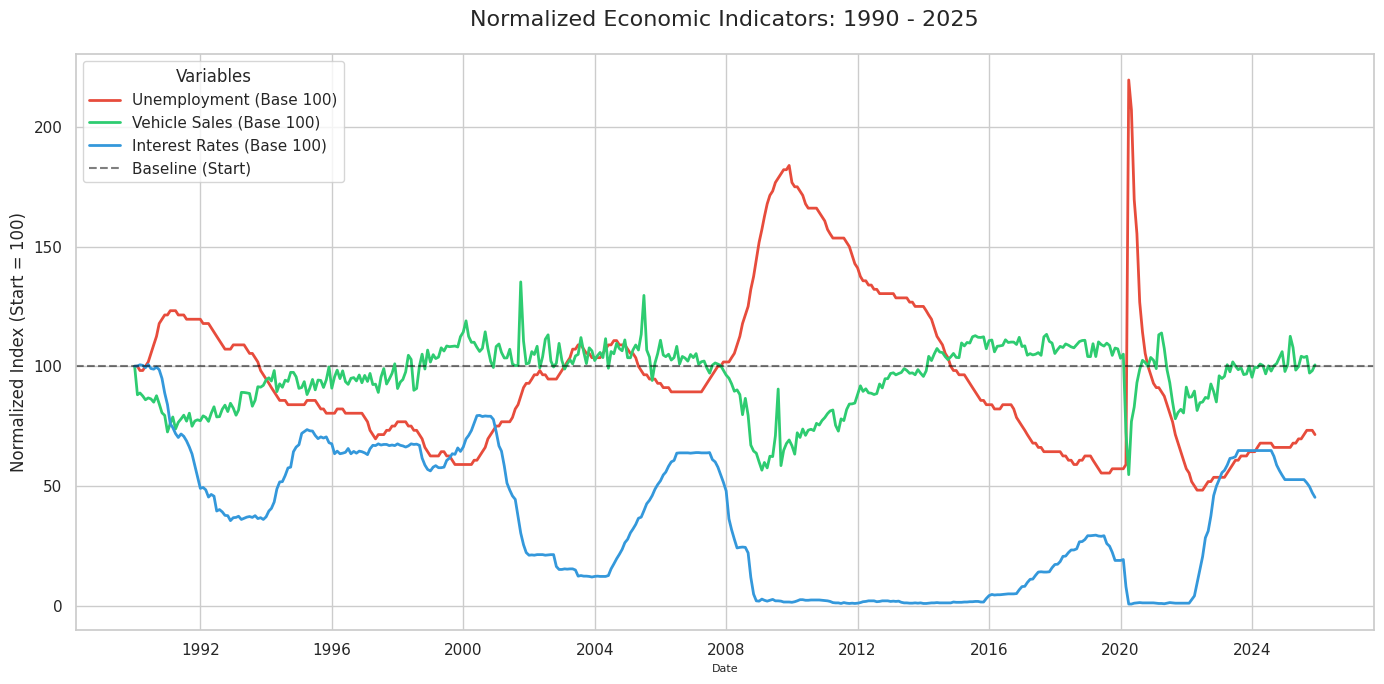

In [35]:
# 1. Set the visual style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 2. Plot each variable
# We use 'label' to identify them in the legend
sns.lineplot(data=df_final, x='observation_date', y='un_Normal', label='Unemployment (Base 100)', color='#e74c3c', linewidth=2)
sns.lineplot(data=df_final, x='observation_date', y='veh_Normal', label='Vehicle Sales (Base 100)', color='#2ecc71', linewidth=2)
sns.lineplot(data=df_final, x='observation_date', y='int_Normal', label='Interest Rates (Base 100)', color='#3498db', linewidth=2)

# 3. Add the "Horizon Line" at 100
# This is critical to see who is growing and who is shrinking
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Baseline (Start)')

# 4. Final Formatting
plt.title('Normalized Economic Indicators: 1990 - 2025', fontsize=16, pad=20)
plt.ylabel('Normalized Index (Start = 100)', fontsize=12)
plt.xlabel('Date', fontsize=8)
plt.legend(title='Variables', loc='upper left')

plt.tight_layout()
plt.show()